<a href="https://colab.research.google.com/github/Orange314159/DataScience/blob/main/MatthewRobsonUnit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install -q pymc-bart
%pip install -q "preliz[full,notebook]"
%pip install -q bambi
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv
import pymc_bart as pmb

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

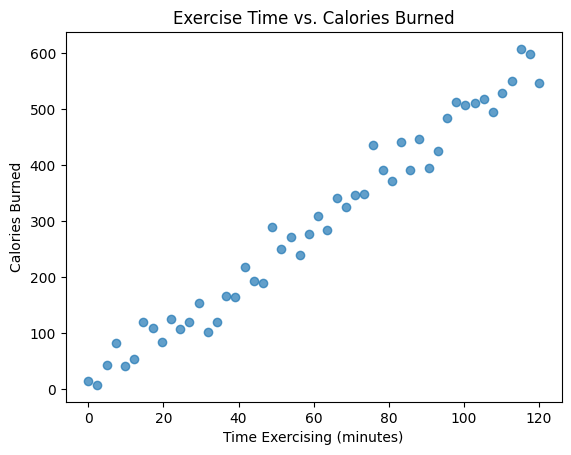

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) ## 42
exercise_time = np.linspace(0, 120, 50)
calories_burned = 5 * exercise_time + np.random.normal(0, 30, 50)

fig, ax = plt.subplots()
ax.scatter(exercise_time, calories_burned, alpha=0.7)
ax.set_title("Exercise Time vs. Calories Burned")
ax.set_xlabel("Time Exercising (minutes)")
ax.set_ylabel("Calories Burned")
plt.show()

Then here I would draw like horizontal lines from (0,50) to (20,50), (20,100) to (40,100), (40,200) (60,200) and so on...  
I would draw a tree that splits based on if the exercising time. That would then give the estimated calories burned.

**Task2**:

What is a decision tree? How do they work?

A decision tree is a approximation method that works by recursively partitioning the data and selecting the ebst value to minimize variance.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

The depth of the tree refers to the longest path from the root node a lead node (of the BST). If the tree is too deep then it will over fit. If it is not deep enough it will underfit.

**Task4:**

How are BART models similar and different from a decision tree?

Both models use binary splitting rules to model the relationships, but BART is a group of many short trees.

**Task5**:

Why would we use a BART model instead of a decision tree?

We would like to use a BART because it works well with high dimensional data (many variables) and provides a posterior.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [17]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [18]:
X = penguins[["flipper_length", "bill_depth", "bill_length"]]

y = penguins["body_mass"].values

In [ ]:
with pm.Model() as model_penguins:
  mu = pmb.BART("mu", X, y, m=50)

  sigma = pm.HalfNormal("sigma", sigma=1)
  y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

  idata_penguins = pm.sample(1000, tune=1000, random_seed=42)

  pm.sample_posterior_predictive(idata_penguins, extend_inferencedata=True)

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

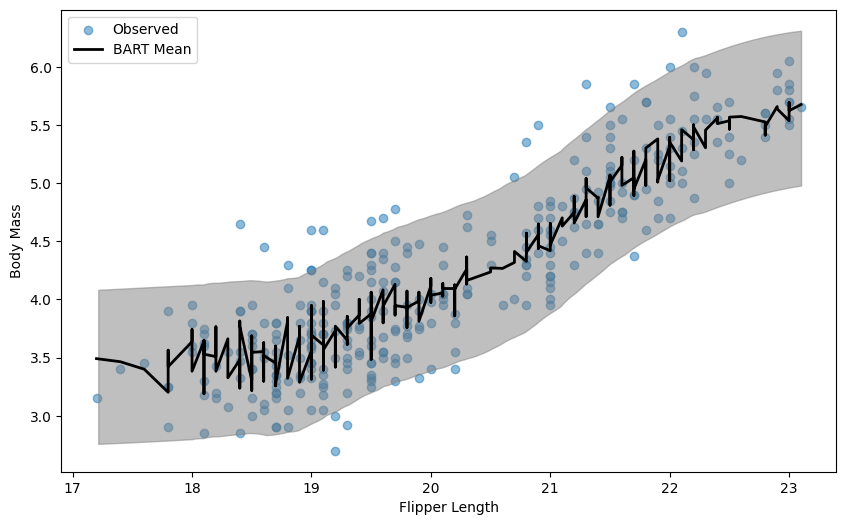

In [20]:
import matplotlib.pyplot as plt
import arviz as az

fig, ax = plt.subplots(figsize=(10, 6))

idx = np.argsort(X["flipper_length"].values)

ax.scatter(X["flipper_length"], y, color="C0", alpha=0.5, label="Observed")

ppc_mean = idata_penguins.posterior_predictive["y_obs"].mean(("chain", "draw")).values
ax.plot(X["flipper_length"].values[idx], ppc_mean[idx], color="black", lw=2, label="BART Mean")

az.plot_hdi(X["flipper_length"], idata_penguins.posterior_predictive["y_obs"], ax=ax, color="gray")

ax.set_xlabel("Flipper Length")
ax.set_ylabel("Body Mass")
ax.legend()
plt.show()

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

Yes, my model seems to have matched the data pretty well, but it seems like it is over fitting a bit. This is because the black line is jumping up and down a lot. But overall I am pretty happy with it.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

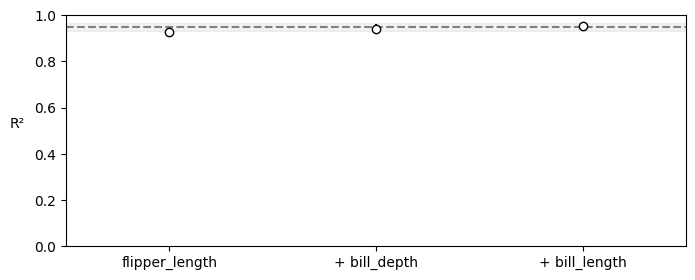

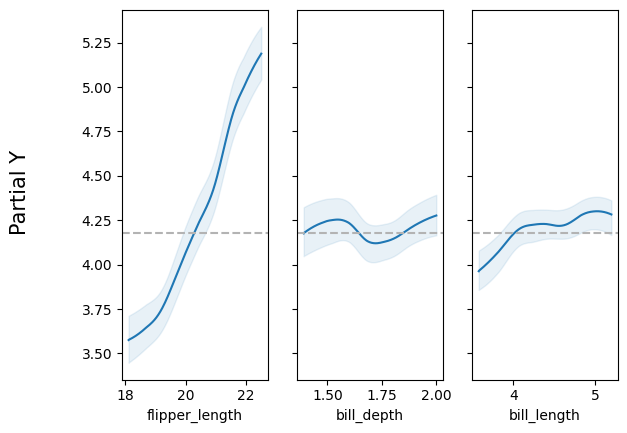

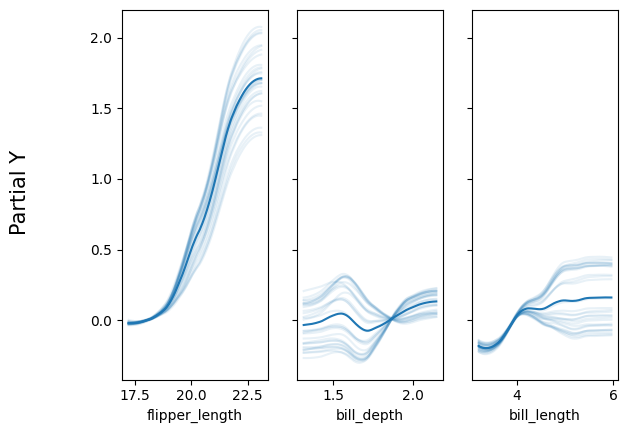

In [23]:
vi_penguins = pmb.compute_variable_importance(idata_penguins, mu, X)
pmb.plot_variable_importance(vi_penguins)
plt.show()

pmb.plot_pdp(mu, X, y, grid=(1, 3))
plt.show()

pmb.plot_ice(mu, X, y, grid=(1, 3))
plt.show()

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

It looks like flipper length is the most significant in predicting body mass in penguins. Even though it is not the best in R^2 we can see that the steepnees of the graph for flipper length is much greater than either of the others. Additionally, looking at the ice plot we can see that the lines are much better grouped than for bill depth and bill length.